# Импорты

In [1]:
%%capture
!pip -q install "unsloth[colab-new]" 2>/dev/null || pip -q install unsloth
!pip -q install trl "datasets>=2.14,<3.0" accelerate peft bitsandbytes transformers sentencepiece evaluate matplotlib pandas
!pip -q install lm-eval

In [2]:
import os, gc, json, random, glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter('ignore')
os.environ['WANDB_DISABLED'] = 'true'
os.environ['TORCHDYNAMO_DISABLE'] = '1'
os.environ['WANDB_MODE']    = 'disabled'

from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer


In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def cuda_mem(label=''):
    if not torch.cuda.is_available():
        print('CUDA not available')
        return
    torch.cuda.synchronize()
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved  = torch.cuda.memory_reserved()  / 1024**2
    max_alloc = torch.cuda.max_memory_allocated() / 1024**2
    print(f'[VRAM] {label}: allocated={allocated:.0f} MB | reserved={reserved:.0f} MB | max_alloc={max_alloc:.0f} MB')

def reset_cuda_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

## 1. Выбор датасета и предобученной модели

### 1.1 Датасет: `IlyaGusev/ru_turbo_alpaca`

Выбран датасет **[ru_turbo_alpaca](https://huggingface.co/datasets/IlyaGusev/ru_turbo_alpaca)** — русскоязычный instruction-following датасет на основе Alpaca, сгенерированный с помощью GPT-4 Turbo.

### 1.2 Предобученная модель: `Qwen2.5-1.5B-Instruct`

Выбрана модель **[Qwen2.5-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct)** от Alibaba в Unsloth-обёртке.


In [4]:
MODEL_NAME        = 'unsloth/Qwen2.5-1.5B-Instruct'
DATASET_NAME      = 'IlyaGusev/ru_turbo_alpaca'

SEED              = 42
MAX_SEQ_LENGTH    = 1024
MAX_TRAIN_SAMPLES = 2000

# Корзинка тестовых промптов для сравнения до/после дообучения
prompts_for_test = [
    'Напиши краткое эссе о важности изучения иностранных языков.',
    'Объясни простыми словами, как работает квантовый компьютер.',
    'Составь рецепт традиционного русского борща.',
    'Какие три главных совета ты бы дал начинающему программисту?',
    'Расскажи о влиянии социальных сетей на современное общество.',
]

set_seed(SEED)
cuda_mem('start')

[VRAM] start: allocated=8 MB | reserved=22 MB | max_alloc=8 MB


## 2. Загрузка модели

In [5]:
reset_cuda_peak()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

cuda_mem('after model load (4-bit)')
print('EOS token:', repr(tokenizer.eos_token), '| id:', tokenizer.eos_token_id)
print('PAD token:', repr(tokenizer.pad_token), '| id:', tokenizer.pad_token_id)

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
[VRAM] after model load (4-bit): allocated=1501 MB | reserved=1530 MB | max_alloc=1517 MB
EOS token: '<|im_end|>' | id: 151645
PAD token: '<|PAD_TOKEN|>' | id: 151665


## 3. Предварительная оценка качества

### 3.1 Корзинка тестовых примеров

Прогоним модель через набор тестовых промптов **до обучения**, чтобы зафиксировать исходное качество генерации и затем сравнить с результатами после дообучения.

In [6]:
FastLanguageModel.for_inference(model)

def generate_chat(
    mdl, tok, user_text,
    system_text='Ты — полезный русскоязычный ассистент.',
    max_new_tokens=300
):
    messages = [
        {'role': 'system', 'content': system_text},
        {'role': 'user',   'content': user_text},
    ]
    prompt = tok.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tok(prompt, return_tensors='pt').to('cuda')
    with torch.no_grad():
        out = mdl.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
        )
    # Декодируем только новые токены (без входного промпта)
    new_tokens = out[0][inputs['input_ids'].shape[1]:]
    return tok.decode(new_tokens, skip_special_tokens=True)

In [7]:
print('=' * 60)
print('КОРЗИНКА ПРОМПТОВ — ДО ДООБУЧЕНИЯ')
print('=' * 60)

results_before = {}
for p in prompts_for_test:
    response = generate_chat(model, tokenizer, p)
    results_before[p] = response
    print(f'\n[ПРОМПТ] {p}')
    print(f'[ОТВЕТ]  {response}')
    print('-' * 60)

КОРЗИНКА ПРОМПТОВ — ДО ДООБУЧЕНИЯ


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[ПРОМПТ] Напиши краткое эссе о важности изучения иностранных языков.
[ОТВЕТ]  Важность изучения иностранных языков:

1. Образовательная ценность:
- Помогает развить мышление, анализировать информацию с разных точек зрения.
- Улучшает навыки чтение, слушание, говорение на новой диалекте.

2. Социальная значимость:
- Определяет границы между культурами и способствует взаимопониманию.
- Снижает шансы на конфликты в мировоззрении.

3. Экономическая привилегия:
- Доступ к информации, специализированным рынкам, культурным событиям.
- Поддержка бизнеса через глобальное сообщество.

4. Интеллектуальные преимущества:
- Развивает мозговые затворы для эффективного обучения.
- Повышает уровень памяти, внимания и логики.

5. Личностные цели:
- Формирует самодисциплину и умение работать под давлением.
- Стимулирует адаптивность к новым условиям жизни.

6. Глобальный курс жизни:
- Нужен в современном мире, где язык - ключевой инструмент общения.

Итак, изуч
------------------------------------------

Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[ПРОМПТ] Объясни простыми словами, как работает квантовый компьютер.
[ОТВЕТ]  Квантовые компьютеры работают по принципу, который называется "квантовой механикой". Это то же самое, что и классические компьютеры, но они используют необычные принципы, которые позволяют им выполнять задачи очень быстро.

В обычных компьютерах данные хранятся в битах (байтах), которые могут иметь только два значения: 0 или 1. Квантовые компьютеры наоборот имеют возможность хранить не только эти два значения, но и их комбинации - это называется "многобитыми" состояниями.

Это позволяет квантовым компьютерам решать сложные проблемы гораздо быстрее, чем классические компьютеры. Например, квантовые компьютеры могут быть использованы для решения численных интегралов, которые обычно решаются с помощью математических моделей. Они также могут улучшить обработку больших объемов данных, так как их способность к одновременной обработке информации гораздо больше, чем у классических компьютеров.
-----------------------

Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[ПРОМПТ] Составь рецепт традиционного русского борща.
[ОТВЕТ]  Конечно, вот рецепт традиционного русского борща:

Ингредиенты:
- 1 кг крупной моркови и картофеля (нарезано)
- 2 луковицы (нарезаны)
- 500 г мяса (птицы или свинины) (смешанное)
- Соль, перец
- Бульон (можно использовать кипяток)

Приготовление:
1. Мелко нарезаем все ингредиенты.
2. В глубокую кастрюлю заливаем бульоном, добавляем соль и перец.
3. Выкладываем нарезанные продукты в кастрюлю.
4. На огонь подогреваем кастрюлю, пока мясо не станет мягким.
5. Пока мясо готовится, можно начать жарить лук. Лук выкладываем на сковороду, накрываем крышкой и ждем, пока он не просветлает.
6. После этого разогреваем кастрюлю, включаем огонь и кладем в неё картофель. Жарим до тех пор, пока он не станет мягким и не станет желтого цвета.
7. Когда картофель
------------------------------------------------------------


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[ПРОМПТ] Какие три главных совета ты бы дал начинающему программисту?
[ОТВЕТ]  1. Начните с базовых знаний: изучите основы языков программирования, таких как Python или Java.

2. Не бойтесь ошибок: в любой области разработки есть места для ошибок и проблем. Главное - это научиться их находить и исправлять.

3. Работайте над своим кодом: постоянное улучшение качества вашего кода будет приводить к повышению его эффективности и удобства использования. 

Помните, что в мире программирования нет таковых простых решений, каждый проект требует тщательного подхода и навыков. Удачи вам на пути к успеху!
------------------------------------------------------------

[ПРОМПТ] Расскажи о влиянии социальных сетей на современное общество.
[ОТВЕТ]  Социальные сети оказывают значительное влияние на современное общество, поскольку они не только упрощают общение и коммуникацию между людьми по всему миру, но и вносят свои коррективы в различные сферы жизни.

1. **Образование**: Сетевые платформы позволяю

### 3.2 Бенчмарк до дообучения (lm-evaluation-harness)

Запускаем **TruthfulQA (mc2)** — задачу, проверяющую фактическую достоверность ответов модели.

In [8]:
BASE_BENCH_DIR = '/content/bench_base'
os.makedirs(BASE_BENCH_DIR, exist_ok=True)

In [9]:
!lm_eval \
  --model hf \
  --model_args pretrained={MODEL_NAME},trust_remote_code=True \
  --tasks truthfulqa_mc2 \
  --device cuda:0 \
  --batch_size 4 \
  --limit 100 \
  --output_path {BASE_BENCH_DIR}

2026-05-18:01:18:39 WARNING  [config.evaluate_config:287] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-05-18:01:18:52 INFO     [_cli.run:388] Selected Tasks: ['truthfulqa_mc2']
2026-05-18:01:18:52 WARNING  [evaluator:184] pretrained=unsloth/Qwen2.5-1.5B-Instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).
2026-05-18:01:18:54 INFO     [evaluator:214] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-05-18:01:18:54 INFO     [evaluator:239] Initializing hf model, with arguments: {'pretrained': 'unsloth/Qwen2.5-1.5B-Instruct', 'trust_remote_code': True}
2026-05-18:01:18:59 INFO     [models.huggingface:286] Using device 'cuda:0'
config.json: 100% 762/762 [00:00<00:00, 4.40MB/s]
tokenizer_config.json: 7.36kB [00:00, 17.1MB/s]
vocab.json: 2.78MB [

## 4. Загрузка и подготовка датасета

In [ ]:
!pip install jsonlines zstandard

In [12]:
ds = load_dataset(DATASET_NAME, trust_remote_code=True)
print(ds)
print('\nПример записи:')
print(ds['train'][0])

Generating train split:   0%|          | 0/29822 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output', 'alternative_output', 'label', 'all_labels', 'agreement', 'overlap'],
        num_rows: 29822
    })
})

Пример записи:
{'instruction': 'Опишите, как сделать горшок из глины.', 'input': '', 'output': 'Для изготовления горшка из глины сначала необходимо взять глину и размешать ее водой до состояния пластилина. Затем нужно сформировать глиняный комок нужной формы и тщательно откачать влагу из глины, чтобы она стала твердой. Горшок нужно обжечь в духовке при высокой температуре, чтобы он стал прочным и непроницаемым.', 'alternative_output': 'Для изготовления горшка из глины нужно выполнить следующие шаги:\n\n1. Подготовить глину: глину необходимо хорошо промыть и измельчить. Если глина слишком сухая, ее нужно замочить.\n\n2. Сформировать горшок: возьмите кусок глины и разминайте его в руках, сделав шарик. Потом начинайте вращать шарик между ладонями, чтоб сформировался цилиндр. Затем используйте пальцы

In [13]:
print('Колонки:', ds['train'].column_names)
print('Размер train:', len(ds['train']))

Колонки: ['instruction', 'input', 'output', 'alternative_output', 'label', 'all_labels', 'agreement', 'overlap']
Размер train: 29822


In [14]:
def to_messages(example):
    """Alpaca-формат (instruction / input / output) → chat-формат."""
    user_text = example['instruction'].strip()
    context   = example.get('input', '').strip()
    if context:
        user_text += '\n\n' + context
    return [
        {'role': 'user',      'content': user_text},
        {'role': 'assistant', 'content': example['output'].strip()},
    ]

def format_text(example):
    """Применяем chat-template токенизатора к каждому примеру."""
    messages = to_messages(example)
    # add_generation_prompt=False: включаем ответ ассистента в обучающий текст
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {'text': text}

In [15]:
raw = ds['train'].shuffle(seed=SEED).select(range(min(MAX_TRAIN_SAMPLES, len(ds['train']))))
raw_formatted = raw.map(format_text, remove_columns=raw.column_names)

print('Пример отформатированного текста:')
print(raw_formatted[0]['text'][:800])

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Пример отформатированного текста:
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Найди пропущенные слова и вставь их в правильном порядке.

Я понял, что ___ жалею о том, что ___  начал ___ этот класс раньше.<|im_end|>
<|im_start|>assistant
Я понял, что я жалею о том, что не начал посещать этот класс раньше.<|im_end|>



In [16]:
dataset = raw_formatted.train_test_split(test_size=0.02, seed=SEED)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1960
    })
    test: Dataset({
        features: ['text'],
        num_rows: 40
    })
})


### Распределение длин последовательностей

Проверяем, что большинство примеров укладывается в `MAX_SEQ_LENGTH`.

Статистика длин (в токенах):
{'count': 500.0, 'mean': 150.0, 'std': 62.3, 'min': 43.0, '50%': 143.5, '90%': 235.2, '95%': 256.0, '99%': 315.1, 'max': 396.0}


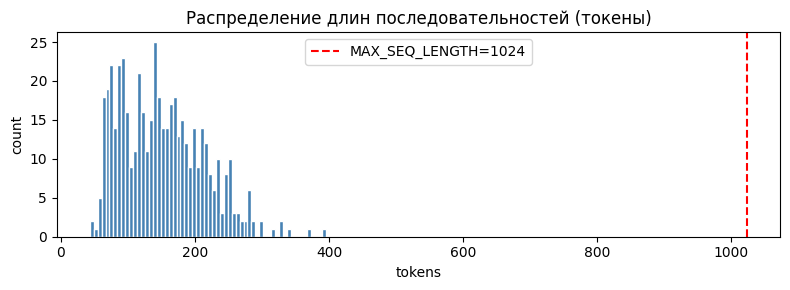

In [17]:
def token_len(text):
    return len(tokenizer(text, add_special_tokens=False).input_ids)

lens = [token_len(x) for x in dataset['train']['text'][:500]]  # ограничиваем для экономии RAM
print('Статистика длин (в токенах):')
print(pd.Series(lens).describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1).to_dict())

plt.figure(figsize=(8, 3))
plt.hist(lens, bins=60, color='steelblue', edgecolor='white')
plt.axvline(MAX_SEQ_LENGTH, color='red', linestyle='--', label=f'MAX_SEQ_LENGTH={MAX_SEQ_LENGTH}')
plt.title('Распределение длин последовательностей (токены)')
plt.xlabel('tokens'); plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

## 5. QLoRA дообучение

In [32]:
del model
gc.collect()
torch.cuda.empty_cache()
reset_cuda_peak()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)
cuda_mem('after reload for training')

==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
[VRAM] after reload for training: allocated=3577 MB | reserved=3648 MB | max_alloc=3593 MB


In [33]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,
    bias='none',
    target_modules=[
        'q_proj', 'k_proj', 'v_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj'
    ],
    use_gradient_checkpointing='unsloth',
    random_state=SEED,
)

In [34]:
def trainable_params_report(mdl):
    trainable = sum(p.numel() for p in mdl.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in mdl.parameters())
    print(f'Обучаемые параметры: {trainable:,} ({100*trainable/total:.2f}%)')
    print(f'Всего параметров:    {total:,}')

trainable_params_report(model)
cuda_mem('after LoRA injection')

Обучаемые параметры: 18,464,768 (1.78%)
Всего параметров:    1,036,449,280
[VRAM] after LoRA injection: allocated=3647 MB | reserved=3680 MB | max_alloc=3648 MB


In [37]:
OUTPUT_DIR = 'sft_runs/qwen25_ru_alpaca'

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    warmup_ratio=0.05,
    learning_rate=3e-5,
    max_grad_norm=0.3,
    lr_scheduler_type='cosine',
    optim='adamw_8bit',
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=10,
    save_strategy='epoch',
    eval_strategy='epoch',
    load_best_model_at_end=True,
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_text_field='text',
    packing=True,
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    args=sft_config,
)

cuda_mem('before training')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Sample packing skipped (custom data collator detected).
[VRAM] before training: allocated=2534 MB | reserved=2666 MB | max_alloc=6364 MB


**learning_rate=3e-5** — при более высоких значениях **lr** модель быстро переобучается.

**num_train_epochs=3** — больше не нужно, возможно следует взять меньше, так как датасет мал.

**per_device_train_batch_size=2** — минимум для стабильных градиентов на T4 с 1.5B моделью в 4-bit.

**gradient_accumulation_steps=4** — эффективный батч = 2×4 = 8. Накапливаем градиенты вместо реального большого батча, экономя VRAM.

**warmup_ratio=0.05** — первые 5% шагов LR растёт с 0 до целевого. Предотвращает резкие обновления в начале, когда веса ещё не адаптированы.

**max_grad_norm=0.3** — обрезка градиентов, нужна для стабилизации лосса, чтобы не появлялись nan-значения.

**lr_scheduler_type='cosine'** — LR плавно убывает по косинусу к концу обучения, что обычно даёт лучшую сходимость чем линейный decay.

**optim='adamw_8bit'** — 8-битный Adam экономит ~75% памяти на состоянии оптимизатора без заметной потери качества.

**packing=True** — упаковка коротких последовательностей в один чанк MAX_SEQ_LENGTH, лучшая утилизация GPU.

**save_strategy/eval_strategy='epoch' + load_best_model_at_end=True** — сохраняем чекпоинт после каждой эпохи, в конце берём лучший по val loss.

In [38]:
train_result = trainer.train()
print(train_result)
cuda_mem('after training')

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,960 | Num Epochs = 3 | Total steps = 735
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Epoch,Training Loss,Validation Loss
1,0.891593,0.968138
2,0.832171,0.967559
3,0.824942,0.973627


Unsloth: Restored added_tokens_decoder metadata in sft_runs/qwen25_ru_alpaca/checkpoint-735/tokenizer_config.json.


TrainOutput(global_step=735, training_loss=0.8553996429962366, metrics={'train_runtime': 939.4184, 'train_samples_per_second': 6.259, 'train_steps_per_second': 0.782, 'total_flos': 8709346554144768.0, 'train_loss': 0.8553996429962366})
[VRAM] after training: allocated=2534 MB | reserved=2666 MB | max_alloc=6364 MB


## 6. Оценка качества после дообучения

### 6.1 Корзинка тестовых примеров — после обучения

In [39]:
FastLanguageModel.for_inference(trainer.model)

print('=' * 60)
print('КОРЗИНКА ПРОМПТОВ — ПОСЛЕ ДООБУЧЕНИЯ')
print('=' * 60)

results_after = {}
for p in prompts_for_test:
    response = generate_chat(trainer.model, tokenizer, p)
    results_after[p] = response
    print(f'\n[ПРОМПТ] {p}')
    print(f'[ОТВЕТ]  {response}')
    print('-' * 60)

Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


КОРЗИНКА ПРОМПТОВ — ПОСЛЕ ДООБУЧЕНИЯ


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[ПРОМПТ] Напиши краткое эссе о важности изучения иностранных языков.
[ОТВЕТ]  Иностранные языки играют важную роль в развитии нашей культуры и мировоззрения, улучшении交际ных навыков и расширении круга возможностей для путешествий и работы за рубежом. Изучение иностранных языков также способствует улучшению межкультурной коммуникации и пониманию различных культур и их традиций.
------------------------------------------------------------


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[ПРОМПТ] Объясни простыми словами, как работает квантовый компьютер.
[ОТВЕТ]  Квантовый компьютер - это устройство, которое использует законы квантовой механики для выполнения вычислений. В обычном компьютере данные хранятся в битах, которые могут иметь только два значения: 0 или 1. Однако в квантовом компьютере данные хранятся в квантах, которые могут иметь все возможные комбинации значений (например, 00, 01, 10 и 11). Это позволяет квантовым компьютерам выполнять вычисления быстрее, чем классические компьютеры.
------------------------------------------------------------


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[ПРОМПТ] Составь рецепт традиционного русского борща.
[ОТВЕТ]  Борщ - это вкусное и свежее блюдо, которое готовится из картофеля, баклажанов, лука, помидоров и куриного груда. Смешайте все ингредиенты в большой кастрюле, добавьте воды до насыщения, доведите до кипения, затем уменьшите огонь и поддерживайте его в течение 15-20 минут. Добавьте соль по вкусу.
------------------------------------------------------------


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[ПРОМПТ] Какие три главных совета ты бы дал начинающему программисту?
[ОТВЕТ]  1. Начни с простых задач и постепенно усложняй их.
2. Обучайся новым языкам программирования, чтобы быть в курсе последних технологий.
3. Не бойся ошибок - они являются частью процесса обучения. Решение проблем важно для успешного развития.
------------------------------------------------------------

[ПРОМПТ] Расскажи о влиянии социальных сетей на современное общество.
[ОТВЕТ]  Социальные сети оказывают огромное влияние на современное общество, в том числе и на образ жизни людей. Они помогают людям находить новые друзья, обмениваться информацией и получать поддержку в трудные моменты. Но они также могут стать причиной эмоционального стресса и повышения уровня зависимости от технологий. Поэтому важно уметь использовать социальные сети в правильном режиме и не превышать свои границы.
------------------------------------------------------------


In [40]:
print('=' * 60)
print('СРАВНЕНИЕ ДО И ПОСЛЕ ДООБУЧЕНИЯ')
print('=' * 60)

for p in prompts_for_test:
    print(f'\n[ПРОМПТ]: {p}')
    print(f'  [ДО    ]: {results_before[p][:400]}')
    print(f'  [ПОСЛЕ ]: {results_after[p][:400]}')
    print('-' * 60)

СРАВНЕНИЕ ДО И ПОСЛЕ ДООБУЧЕНИЯ

[ПРОМПТ]: Напиши краткое эссе о важности изучения иностранных языков.
  [ДО    ]: Важность изучения иностранных языков:

1. Образовательная ценность:
- Помогает развить мышление, анализировать информацию с разных точек зрения.
- Улучшает навыки чтение, слушание, говорение на новой диалекте.

2. Социальная значимость:
- Определяет границы между культурами и способствует взаимопониманию.
- Снижает шансы на конфликты в мировоззрении.

3. Экономическая привилегия:
- Доступ к информ
  [ПОСЛЕ ]: Иностранные языки играют важную роль в развитии нашей культуры и мировоззрения, улучшении交际ных навыков и расширении круга возможностей для путешествий и работы за рубежом. Изучение иностранных языков также способствует улучшению межкультурной коммуникации и пониманию различных культур и их традиций.
------------------------------------------------------------

[ПРОМПТ]: Объясни простыми словами, как работает квантовый компьютер.
  [ДО    ]: Квантовые компьютеры работа

### 6.2 Бенчмарк после дообучения

Запускаем тот же `truthfulqa_mc2` на дообученной модели (с LoRA-адаптером), чтобы сравнить с базовым результатом.

In [41]:
ADAPTER_DIR = '/content/artifacts/qwen25_ru_alpaca_adapter'
os.makedirs(ADAPTER_DIR, exist_ok=True)

trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print('Адаптер сохранён в:', ADAPTER_DIR)

Unsloth: Restored added_tokens_decoder metadata in /content/artifacts/qwen25_ru_alpaca_adapter/tokenizer_config.json.


Адаптер сохранён в: /content/artifacts/qwen25_ru_alpaca_adapter


In [42]:
SFT_BENCH_DIR = '/content/bench_sft'
os.makedirs(SFT_BENCH_DIR, exist_ok=True)

!lm_eval \
  --model hf \
  --model_args pretrained={MODEL_NAME},peft={ADAPTER_DIR},trust_remote_code=True \
  --tasks truthfulqa_mc2 \
  --device cuda:0 \
  --batch_size 4 \
  --limit 100 \
  --output_path {SFT_BENCH_DIR}

2026-05-18:03:06:10 WARNING  [config.evaluate_config:287] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-05-18:03:06:23 INFO     [_cli.run:388] Selected Tasks: ['truthfulqa_mc2']
2026-05-18:03:06:23 WARNING  [evaluator:184] pretrained=unsloth/Qwen2.5-1.5B-Instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).
2026-05-18:03:06:27 INFO     [evaluator:214] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-05-18:03:06:27 INFO     [evaluator:239] Initializing hf model, with arguments: {'pretrained': 'unsloth/Qwen2.5-1.5B-Instruct', 'peft': '/content/artifacts/qwen25_ru_alpaca_adapter', 'trust_remote_code': True}
2026-05-18:03:06:33 INFO     [models.huggingface:286] Using device 'cuda:0'
2026-05-18:03:06:35 INFO     [models.huggingface:579] Model par

In [43]:
def read_lm_eval_latest(bench_dir):
    """Читаем последний json-результат из директории lm_eval."""
    files = sorted(glob.glob(os.path.join(bench_dir, '**', '*.json'), recursive=True))
    if not files:
        print(f'Файлы результатов не найдены в {bench_dir}')
        return {}
    with open(files[-1]) as f:
        j = json.load(f)
    return j.get('results', {})

base_res = read_lm_eval_latest(BASE_BENCH_DIR)
sft_res  = read_lm_eval_latest(SFT_BENCH_DIR)

task = 'truthfulqa_mc2'

def get_metric(res, task, keys=('acc,none', 'acc')):
    task_res = res.get(task, {})
    for k in keys:
        if k in task_res:
            return task_res[k]
    return None

base_acc = get_metric(base_res, task)
sft_acc  = get_metric(sft_res,  task)

print(f'TruthfulQA MC2:')
print(f'  До дообучения:    {base_acc}')
print(f'  После дообучения: {sft_acc}')

if isinstance(base_acc, (int, float)) and isinstance(sft_acc, (int, float)):
    delta = sft_acc - base_acc
    print(f'  Изменение: {delta:+.4f} ({delta*100:+.2f} п.п.)')

TruthfulQA MC2:
  До дообучения:    0.4685920828615556
  После дообучения: 0.4453068640682112
  Изменение: -0.0233 (-2.33 п.п.)


Результаты даже ухудшились, пусть ухудшение и не статзначимо. Объяснить можно тем, что Fine-tuning на ru_turbo_alpaca обучает модель как отвечать (структура, стиль, следование инструкции), но не добавляет фактических знаний. TruthfulQA проверяет именно фактическую достоверность. Кроме того, при дообучении на узком домене (2000 русских инструкций) модель может частично забывать общие знания из pretraining.